## In-Class Guided Exercise:

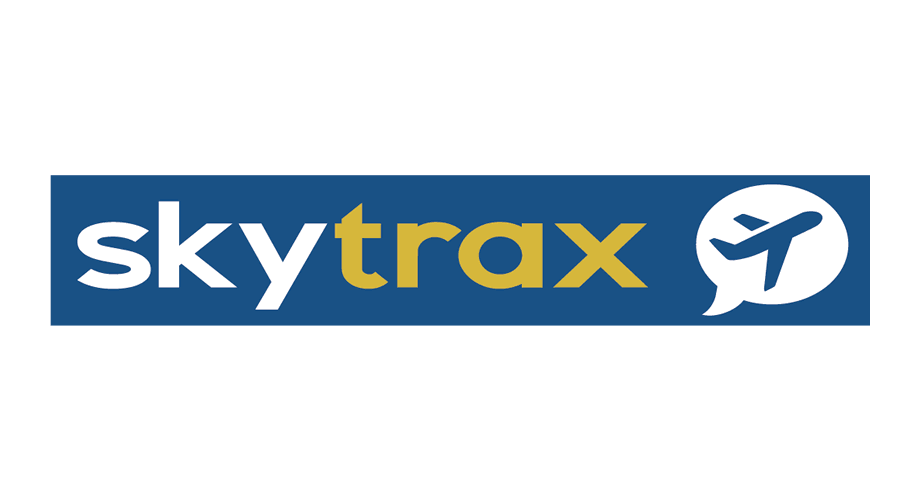

In [1]:
import requests
import httpx  # if you want to use httpx instead of requests

import pandas as pd
from bs4 import BeautifulSoup
from time import sleep


### Steps on web scraping using BeautifulSoup:
#### 1. Use `requests` to access the url of the web page you want to scrape

In [2]:
url="https://www.airlinequality.com/airline-reviews/qatar-airways/page/1/?sortby=post_date%3ADesc&pagesize=100"
# Your code here


In [3]:
# Your code here
html_page = requests.get(url)
html_page
# 200 mean OK 

<Response [200]>

In [4]:
html_page.text[:2000] # First 2000 characters of the HTML

'<!doctype html>\n\n<!--[if lt IE 7]> <html class="no-js lt-ie9 lt-ie8 lt-ie7 lt-ie10" lang="en-GB"> <![endif]-->\n<!--[if IE 7]>    <html class="no-js lt-ie9 lt-ie8 lt-ie10" lang="en-GB"> <![endif]-->\n<!--[if IE 8]>    <html class="no-js lt-ie9 lt-ie10" lang="en-GB"> <![endif]-->\n<!--[if IE 9]>    <html class="no-js lt-ie10" lang="en-GB"> <![endif]-->\n<!--[if gt IE 8]><!-->\n<html lang="en-GB">\n<!--<![endif]-->\n\n<head>\n    <meta charset="utf-8">\n\n    <title>Qatar Airways Customer Reviews - SKYTRAX</title>\n\n    <!-- Google Chrome Frame for IE -->\n    <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">\n\n    <!-- mobile meta -->\n    <meta name="HandheldFriendly" content="True">\n    <meta name="MobileOptimized" content="320">\n    <meta name="viewport"\n        content="width=device-width, initial-scale=1.0, minimum-scale=1.0, maximum-scale=1.0, user-scalable=no" />\n    <!-- icons & favicons -->\n    <!-- <link rel="apple-touch-icon" href="https://www.airlinequ

#### 2. Now that we have the web page, we can parse it with `BeautifulSoup`:

In [5]:
# Your code here

soup = BeautifulSoup(html_page.text, 'html.parser')

- Get the title of the page using the tag 'title':

In [6]:
soup.title


<title>Qatar Airways Customer Reviews - SKYTRAX</title>

#### 3. Get all the items in that page
- Use `inspect` on the web page to know how to collect the items 
- Create a variable that contains all the items in that web page


In [15]:
# Find all the elements in the page

# complete the code
skytrax= soup.find_all('article',itemprop='review')


len(skytrax)

100

In [16]:
# Check one of the items collected
skytrax[0]

<article class="comp comp_media-review-rated list-item media position-content review-949910" itemprop="review" itemscope="" itemtype="http://schema.org/Review">
<meta content="2026-07-09" itemprop="datePublished"/>
<div class="rating-10" itemprop="reviewRating" itemscope="" itemtype="http://schema.org/Rating">
<span itemprop="ratingValue">5</span>/<span itemprop="bestRating">10</span>
</div>
<div class="body" id="anchor949910">
<h2 class="text_header">“ they declined a small goodwill gesture”</h2>
<h3 class="text_sub_header userStatusWrapper">
<span itemprop="author" itemscope="" itemtype="http://schema.org/Person">
<span itemprop="name">Paul Nicoll</span></span> (United Kingdom) <time datetime="2026-07-09" itemprop="datePublished">9th July 2026</time></h3>
<div class="tc_mobile">
<div class="text_content" itemprop="reviewBody">✅ <strong><a href="https://www.airlinequality.com/verified-reviews/"><em>Trip Verified</em></a></strong> |   There were several issues, including the onboard se

#### 4. Using one item, try to collect the information that you want to scrape

##### 4.1 *Review Title (remove the internal double quotation)*

In [30]:
skytrax[0].find(class_='text_header').text.replace('“','').replace('”','').replace('"','').strip()

'they declined a small goodwill gesture'

##### 4.2 *Reviewer Name*

In [27]:
skytrax[0].find(itemprop='name').text

'Paul Nicoll'

##### 4.3 *Reviewer Location* (Challenge)

In [44]:
list(skytrax[0].find('h3'))[2].replace('(','').replace(')','').strip()

'United Kingdom'

##### 4.4 *Review Time (in the format yyyy-mm-dd)* 

In [62]:
skytrax[0].find('time')['datetime']

'2026-07-09'

##### 4.5 *Verified?*

In [71]:
skytrax[0].find('em').text

'Trip Verified'

##### 4.6 *Get the Review*

In [81]:
# review

skytrax[0].find(itemprop="reviewBody").text.split('|')[1].strip()

'There were several issues, including the onboard service, condition of the lavatory, problems with the moving map and a disappointing breakfas. I contacted Customer Care, and while they responded promptly, I was disappointed that they declined even a small goodwill gesture.'

##### 4.7 *Get the Aircraft model*

In [104]:
#Aircraft

skytrax[2].find('td', class_="review-rating-header aircraft").find_next_sibling('td').text

'A350-1000'

##### 4.8 *Get Type of Traveller*

In [108]:
#Type Of Traveller

skytrax[2].find('td',class_='review-rating-header type_of_traveller').find_next_sibling('td').text


'Couple Leisure'

##### 4.9 *Get the Seat Type*

In [109]:
skytrax[2].find('td',class_='review-rating-header cabin_flown').find_next_sibling('td').text

'Business Class'

##### 4.10 *Get the Route*

In [110]:
skytrax[2].find('td',class_='review-rating-header route').find_next_sibling('td').text

'Hong Kong to Doha'

##### 4.11 *Get the Date Flown*

In [111]:
skytrax[2].find('td',class_='review-rating-header date_flown').find_next_sibling('td').text

'May 2026'

##### 4.12 *Get the overall rating(the orange circle to the left)*

In [120]:
skytrax[0].find(itemprop="ratingValue").text + '/' + skytrax[0].find(itemprop="bestRating").text

'5/10'

#### Get the Ratings/Stars

> We are facing a new issue here. \
> There is no direct rating stars from the output. \
> The star that is filled will be 'star fill' while the unfilled star is 'star'. \
> We need to create a function to calculate exactly number of stars for each rating. \
> create a function `get_stars` to calculate how many stars.
> it would take a complete `td class element` same as the following and returns number of `star fill`:

```html
 <td class="review-rating-stars stars">
     <span class="star fill">1</span>
     <span class="star fill">2</span>
     <span class="star fill">3</span>
     <span class="star">4</span>
     <span class="star">5</span></td> 
```

In [121]:
# Creating a function to calculate the number of stars
def get_stars(x):
    count=0
    for i in x.find_all('span', class_='star fill'):
        count = count+1
    return count
    
    # complete the code for the function

##### 4.13 *Get Seat Comfort rating*

> Notice that the tag and the class name for all the following ratings are the same which is 'review-rating-stars stars'. \
> We are able to do it for the first star rating but not for the rest. \
> To solve this, we have to search for the class name that contains the star rating title then use 'find_next_siblings' to seach for the next 'td' class.


In [125]:
get_stars(skytrax[1].find('td',class_='review-rating-header seat_comfort').find_next_sibling('td'))

3

##### 4.14 *Get Cabin Staff Service rating*

In [127]:
get_stars(skytrax[0].find('td',class_='review-rating-header cabin_staff_service').find_next_sibling('td'))

3

##### 4.15 *Get Food & Beverages rating*

In [128]:
get_stars(skytrax[0].find('td',class_='review-rating-header food_and_beverages').find_next_sibling('td'))

3

##### 4.16 *Get Inflight Entertainment rating*

In [129]:
get_stars(skytrax[0].find('td',class_='review-rating-header inflight_entertainment').find_next_sibling('td'))

3

##### 4.17 *Get Ground Service rating*

In [130]:
get_stars(skytrax[0].find('td',class_='review-rating-header ground_service').find_next_sibling('td'))

5

##### 4.18 *Get Value For Money rating*

In [131]:
get_stars(skytrax[0].find('td',class_='review-rating-header value_for_money').find_next_sibling('td'))

3

##### 4.19 *Get Recommended*

In [134]:
skytrax[2].find('td',class_='review-rating-header recommended').find_next_sibling('td').text

'yes'

#### 5. Collect all the information of all the items using `loops`
- Now, once we know how to get in information we want from one item, we can now collect all the information from all the items using `for loop`
- **First of all**, we need to create a list for each info we want to collect and append the scraped info to those lists

In [139]:
# define the empty lists 
rev_title=[]
rev_name=[]
rev_location=[]
rev_time=[]
verified=[]
review=[]
air_model=[]
type_of_traveller=[]
seat_type=[]
route=[]
date_flown=[]
overall_rating=[]
seat_rating=[]
cabin_rating=[]
food_rating=[]
enter_rating=[]
ground_s_rating=[]
value_of_money_rating=[]
recommended=[]

# your code here

for i in skytrax:
    try:
        rev_title.append(i.find(class_='text_header').text.replace('“','').replace('”','').replace('"','').strip())
    except:
        rev_title.append(None)
    try:
        rev_name.append(i.find(itemprop='name').text)
    except:
        rev_name.append(None)
    try:
        rev_location.append(list(i.find('h3'))[2].replace('(','').replace(')','').strip())
    except:
        rev_location.append(None)
    try:
        rev_time.append(i.find('time')['datetime'])
    except:
        rev_time.append(None)
    try:
        verified.append(i.find('em').text)
    except:
        verified.append(None)
    try:
        review.append(i.find(itemprop="reviewBody").text.split('|')[1].strip())
    except:
        review.append(None)
    try:
        air_model.append(i.find('td', class_="review-rating-header aircraft").find_next_sibling('td').text)
    except:
        air_model.append(None)
    try:
        type_of_traveller.append(i.find('td',class_='review-rating-header type_of_traveller').find_next_sibling('td').text)
    except:
        type_of_traveller.append(None)
    try:
        seat_type.append(i.find('td',class_='review-rating-header cabin_flown').find_next_sibling('td').text)
    except:
        seat_type.append(None)
    try:
        route.append(i.find('td',class_='review-rating-header route').find_next_sibling('td').text)
    except:
        route.append(None)
    try:
        date_flown.append(i.find('td',class_='review-rating-header date_flown').find_next_sibling('td').text)
    except:
        date_flown.append(None)
    try:
        overall_rating.append(i.find(itemprop="ratingValue").text + '/' + skytrax[0].find(itemprop="bestRating").text)
    except:
        overall_rating.append(None)
    try:
        seat_rating.append(get_stars(i.find('td',class_='review-rating-header seat_comfort').find_next_sibling('td')))
    except:
        seat_rating.append(None)
    try:
        cabin_rating.append(get_stars(i.find('td',class_='review-rating-header cabin_staff_service').find_next_sibling('td')))
    except:
        cabin_rating.append(None)
    try:
        food_rating.append(get_stars(i.find('td',class_='review-rating-header food_and_beverages').find_next_sibling('td')))
    except:
        food_rating.append(None)
    try:
        enter_rating.append(get_stars(i.find('td',class_='review-rating-header inflight_entertainment').find_next_sibling('td')))
    except:
        enter_rating.append(None)
    try:
        ground_s_rating.append(get_stars(i.find('td',class_='review-rating-header ground_service').find_next_sibling('td')))
    except:
        ground_s_rating.append(None)
    try:
        value_of_money_rating.append(get_stars(i.find('td',class_='review-rating-header value_for_money').find_next_sibling('td')))
    except:
        value_of_money_rating.append(None)
    try:
        recommended.append(i.find('td',class_='review-rating-header recommended').find_next_sibling('td').text)
    except:
        recommended.append(None)



#### 6. Modify the previous `loop` to collect multiple web pages 
- In below code, we collect the web pages from 1 to 5 of that site
- Notice that the only difference from page to page is the page number which we can use in the `for loop` using the curly brackets `{}`

In [147]:
# define the empty lists 
rev_title=[]
rev_name=[]
rev_location=[]
rev_time=[]
verified=[]
review=[]
air_model=[]
type_of_traveller=[]
seat_type=[]
route=[]
date_flown=[]
overall_rating=[]
seat_rating=[]
cabin_rating=[]
food_rating=[]
enter_rating=[]
ground_s_rating=[]
value_of_money_rating=[]
recommended=[]

# your code here

for p in range(1,6):
    url=f"https://www.airlinequality.com/airline-reviews/qatar-airways/page/{p}/?sortby=post_date%3ADesc&pagesize=100"
    html_page = requests.get(url)
    while html_page.status_code != 200:
        html_page = requests.get(url)
    soup = BeautifulSoup(html_page.text, 'html.parser')
    skytrax= soup.find_all('article',itemprop='review')

    for i in skytrax:
        try:
            rev_title.append(i.find(class_='text_header').text.replace('“','').replace('”','').replace('"','').strip())
        except:
            rev_title.append(None)
        try:
            rev_name.append(i.find(itemprop='name').text)
        except:
            rev_name.append(None)
        try:
            rev_location.append(list(i.find('h3'))[2].replace('(','').replace(')','').strip())
        except:
            rev_location.append(None)
        try:
            rev_time.append(i.find('time')['datetime'])
        except:
            rev_time.append(None)
        try:
            verified.append(i.find('em').text)
        except:
            verified.append(None)
        try:
            review.append(i.find(itemprop="reviewBody").text.split('|')[1].strip())
        except:
            review.append(None)
        try:
            air_model.append(i.find('td', class_="review-rating-header aircraft").find_next_sibling('td').text)
        except:
            air_model.append(None)
        try:
            type_of_traveller.append(i.find('td',class_='review-rating-header type_of_traveller').find_next_sibling('td').text)
        except:
            type_of_traveller.append(None)
        try:
            seat_type.append(i.find('td',class_='review-rating-header cabin_flown').find_next_sibling('td').text)
        except:
            seat_type.append(None)
        try:
            route.append(i.find('td',class_='review-rating-header route').find_next_sibling('td').text)
        except:
            route.append(None)
        try:
            date_flown.append(i.find('td',class_='review-rating-header date_flown').find_next_sibling('td').text)
        except:
            date_flown.append(None)
        try:
            overall_rating.append(i.find(itemprop="ratingValue").text + '/' + skytrax[0].find(itemprop="bestRating").text)
        except:
            overall_rating.append(None)
        try:
            seat_rating.append(get_stars(i.find('td',class_='review-rating-header seat_comfort').find_next_sibling('td')))
        except:
            seat_rating.append(None)
        try:
            cabin_rating.append(get_stars(i.find('td',class_='review-rating-header cabin_staff_service').find_next_sibling('td')))
        except:
            cabin_rating.append(None)
        try:
            food_rating.append(get_stars(i.find('td',class_='review-rating-header food_and_beverages').find_next_sibling('td')))
        except:
            food_rating.append(None)
        try:
            enter_rating.append(get_stars(i.find('td',class_='review-rating-header inflight_entertainment').find_next_sibling('td')))
        except:
            enter_rating.append(None)
        try:
            ground_s_rating.append(get_stars(i.find('td',class_='review-rating-header ground_service').find_next_sibling('td')))
        except:
            ground_s_rating.append(None)
        try:
            value_of_money_rating.append(get_stars(i.find('td',class_='review-rating-header value_for_money').find_next_sibling('td')))
        except:
            value_of_money_rating.append(None)
        try:
            recommended.append(i.find('td',class_='review-rating-header recommended').find_next_sibling('td').text)
        except:
            recommended.append(None)



#### 7. Create a DataFrame to save all the scraped info. into a table.


In [148]:
skytrax_df= pd.DataFrame({'Review Title': rev_title, 'Reviewer Name': rev_name,
             'Reviewer Location': rev_location,
             'Review Time': rev_time,
             'Verified': verified,
             'Review': review,
             'Aircraft Model': air_model,
             'Type Of Traveller': type_of_traveller,
             'Seat Type': seat_type,
             'Route': route,
             'Date flown': date_flown,
             'Overall Rating': overall_rating,
             'Seat rating': seat_rating,
             'Cabin rating': cabin_rating,
             'Food rating': food_rating, 
             'Inflight Entertainment rating': enter_rating, 
             'Ground rating': ground_s_rating,
             'Value of money': value_of_money_rating,
             'Recommended': recommended})

# your code here

In [149]:
skytrax_df

,Review Title,Reviewer Name,Reviewer Location,Review Time,Verified,Review,Aircraft Model,Type Of Traveller,Seat Type,Route,Date flown,Overall Rating,Seat rating,Cabin rating,Food rating,Inflight Entertainment rating,Ground rating,Value of money,Recommended
0,they declined a small goodwill gesture,Paul Nicoll,United Kingdom,2026-07-09,Trip Verified,"There were several issues, including the onboa...",NaN,Solo Leisure,Business Class,Sydney to Doha,July 2026,5/10,5.0,3.0,3.0,3.0,5.0,3,no
1,showed incredible leadership,Maher AlShaaban,Qatar,2026-06-24,Trip Verified,Two and a half hours before our flight to Indo...,NaN,Family Leisure,Economy Class,Doha to Jakarta,June 2026,10/10,3.0,5.0,4.0,1.0,5.0,5,yes
2,just had to just sleep,Alwaleed Althani,Qatar,2026-06-06,Trip Verified,Came in on a connecting flight on Cathay Pacif...,A350-1000,Couple Leisure,Business Class,Hong Kong to Doha,May 2026,9/10,4.0,4.0,NaN,NaN,3.0,4,yes
3,sandwich no choice,Alwaleed Althani,Qatar,2026-06-06,Trip Verified,A330 comfortable but very much underwhelming. ...,A330-200,Couple Leisure,Business Class,CAN to HKG,May 2026,6/10,3.0,3.0,1.0,1.0,3.0,3,yes
4,cabin crew was professional and friendly,L Casine,France,2026-05-29,Trip Verified,I recently flew with Qatar Airways on a Boeing...,Boeing 777-300ER,Business,Economy Class,Guangzhou to Doha,May 2026,6/10,2.0,5.0,5.0,5.0,2.0,2,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,appreciate the good and warm services,Rizaldy Ilaya,Philippines,2023-06-03,Trip Verified,I appreciate the good and warm services provid...,NaN,Solo Leisure,Economy Class,Lagos to Manila via Doha,June 2023,9/10,4.0,5.0,5.0,4.0,5.0,4,yes
496,switched us from suites,W Peale,United States,2023-05-27,Trip Verified,"Qatar is usually very good, but watch out. The...",Boeing 777-300ER,Couple Leisure,Business Class,Doha to Ord,May 2023,6/10,2.0,5.0,5.0,4.0,1.0,2,yes
497,Great seats in business class,Joanna Michael dit Miguel,United Kingdom,2023-05-24,Trip Verified,Great seats in business class qsuite and very ...,Boeing 777,Solo Leisure,Business Class,London to Abu Dhabi via Doha,May 2023,3/10,4.0,4.0,3.0,5.0,3.0,1,no
498,they put me in exit row center,R Geares,United States,2023-05-24,Trip Verified,Very frustrating experience with the airline. ...,Boeing 777-300ER,Business,Economy Class,Doha to Chicago,May 2023,4/10,3.0,3.0,3.0,4.0,2.0,2,no


#### 8. Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [150]:
# Save the output to a csv file (excluding the index)
skytrax_df.to_csv('skytrax', index=False)
# your code here